Using device: cuda

Loading CLIP model...
Loading image: G:\Thesis\ImageRetrieval\test\Male_Accountant\0.155_0000_190502.jpg


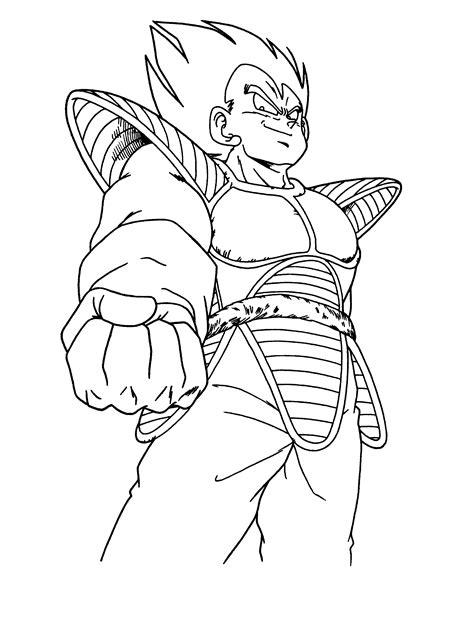


FILTERING TEST RESULTS

📊 SCORES:
  Max Generic Positive: 0.1738 ('person')
  Max Negative:         0.1765 ('document')
  Threshold:            0.1738 (generic_pos - 0)
  Margin:               -0.0027

🎯 DECISION: ❌ REJECT
  Logic: max_negative (0.1765) >= threshold (0.1738)

📋 TOP 5 GENERIC POSITIVE MATCHES:
  1. 0.1738 - 'person'
  2. 0.1711 - 'a picture of a Human Accountant'
  3. 0.1626 - 'people'
  4. 0.1617 - 'person portrait'
  5. 0.1560 - 'face'

📋 TOP 5 NEGATIVE MATCHES:
  1. 0.1765 - 'document'
  2. 0.1709 - 'printed form'
  3. 0.1662 - 'cartoon'
  4. 0.1645 - 'clothing item'
  5. 0.1637 - 'empty shirt'



In [33]:
import torch
import numpy as np
from transformers import AutoProcessor, AutoModel
from PIL import Image

# ============================================================
# TEST SINGLE IMAGE FILTERING
# ============================================================

def test_image_filter(
    image_path: str,
    generic_positive_prompts=["a picture of a Human Accountant", "person", "face", "a photo of a person", "human face", "person portrait", "people"],
    negative_prompts=[
        "document",
        "paper document",
        "text on paper",
        "printed form",
        "business card",
        "logo",
        "company logo",
        "signboard",
        "clothing item",
        "empty shirt",
        "suit on hanger",
        "office supplies",
        "calculator",
        "keyboard",
        "computer screen",
        "cartoon",
        "animal",
        "cat",
        "dog",
        "shirt"
    ],
    dominance_margin=0.05,
    model_name="openai/clip-vit-large-patch14"
):
    """
    Test if a single image would pass the filtering logic.
    
    Returns:
        dict with decision, scores, and detailed breakdown
    """
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}\n")
    
    # Load CLIP
    print("Loading CLIP model...")
    processor = AutoProcessor.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()
    
    # Load and process image
    print(f"Loading image: {image_path}")
    image = Image.open(image_path).convert("RGB")
    display(image)
    
    # Get image embedding
    image_inputs = processor(images=image, return_tensors="pt").to(device)
    
    with torch.no_grad():
        image_features = model.get_image_features(**image_inputs)
    
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    img_emb = image_features.cpu().numpy().astype("float32")[0]
    img_emb = img_emb / np.linalg.norm(img_emb)
    
    # Get generic positive embeddings
    generic_pos_inputs = processor(
        text=generic_positive_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)
    
    with torch.no_grad():
        generic_pos_features = model.get_text_features(**generic_pos_inputs)
    
    generic_pos_features = generic_pos_features / generic_pos_features.norm(dim=-1, keepdim=True)
    generic_pos_embs = generic_pos_features.cpu().numpy().astype("float32")
    
    # Get negative embeddings
    neg_inputs = processor(
        text=negative_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)
    
    with torch.no_grad():
        neg_features = model.get_text_features(**neg_inputs)
    
    neg_features = neg_features / neg_features.norm(dim=-1, keepdim=True)
    neg_embs = neg_features.cpu().numpy().astype("float32")
    
    # Calculate similarities
    generic_pos_sims = img_emb @ generic_pos_embs.T
    neg_sims = img_emb @ neg_embs.T
    
    max_generic_pos = np.max(generic_pos_sims)
    max_neg = np.max(neg_sims)
    
    # Get which prompts had max scores
    max_pos_idx = np.argmax(generic_pos_sims)
    max_neg_idx = np.argmax(neg_sims)
    
    # Decision logic
    threshold = max_generic_pos - dominance_margin
    would_keep = max_neg < threshold
    
    # Print results
    print("\n" + "="*70)
    print("FILTERING TEST RESULTS")
    print("="*70)
    
    print(f"\n📊 SCORES:")
    print(f"  Max Generic Positive: {max_generic_pos:.4f} ('{generic_positive_prompts[max_pos_idx]}')")
    print(f"  Max Negative:         {max_neg:.4f} ('{negative_prompts[max_neg_idx]}')")
    print(f"  Threshold:            {threshold:.4f} (generic_pos - {dominance_margin})")
    print(f"  Margin:               {max_generic_pos - max_neg:.4f}")
    
    print(f"\n🎯 DECISION: {'✅ KEEP' if would_keep else '❌ REJECT'}")
    print(f"  Logic: max_negative ({max_neg:.4f}) {'<' if would_keep else '>='} threshold ({threshold:.4f})")
    
    print(f"\n📋 TOP 5 GENERIC POSITIVE MATCHES:")
    top_pos_indices = np.argsort(generic_pos_sims)[::-1][:5]
    for i, idx in enumerate(top_pos_indices, 1):
        print(f"  {i}. {generic_pos_sims[idx]:.4f} - '{generic_positive_prompts[idx]}'")
    
    print(f"\n📋 TOP 5 NEGATIVE MATCHES:")
    top_neg_indices = np.argsort(neg_sims)[::-1][:5]
    for i, idx in enumerate(top_neg_indices, 1):
        print(f"  {i}. {neg_sims[idx]:.4f} - '{negative_prompts[idx]}'")
    
    print("\n" + "="*70)
    
    # Return structured result
    return {
        "decision": "KEEP" if would_keep else "REJECT",
        "would_keep": would_keep,
        "max_generic_positive_score": float(max_generic_pos),
        "max_generic_positive_prompt": generic_positive_prompts[max_pos_idx],
        "max_negative_score": float(max_neg),
        "max_negative_prompt": negative_prompts[max_neg_idx],
        "threshold": float(threshold),
        "margin": float(max_generic_pos - max_neg),
        "dominance_margin": dominance_margin,
        "all_generic_positive_scores": {prompt: float(score) for prompt, score in zip(generic_positive_prompts, generic_pos_sims)},
        "all_negative_scores": {prompt: float(score) for prompt, score in zip(negative_prompts, neg_sims)}
    }


# ============================================================
# BATCH TEST MULTIPLE IMAGES
# ============================================================

def test_multiple_images(image_paths, dominance_margin=0.05):
    """
    Test multiple images and show summary.
    """
    results = []
    
    for img_path in image_paths:
        print(f"\n{'='*70}")
        print(f"Testing: {img_path}")
        print(f"{'='*70}")
        
        result = test_image_filter(img_path, dominance_margin=dominance_margin)
        results.append({
            "path": img_path,
            **result
        })
    
    # Summary
    print(f"\n\n{'='*70}")
    print("SUMMARY")
    print(f"{'='*70}\n")
    
    kept = sum(1 for r in results if r["would_keep"])
    total = len(results)
    
    print(f"Total Images: {total}")
    print(f"Kept:         {kept} ({kept/total*100:.1f}%)")
    print(f"Rejected:     {total-kept} ({(total-kept)/total*100:.1f}%)")
    
    print(f"\nPer-Image Results:")
    for r in results:
        decision_emoji = "✅" if r["would_keep"] else "❌"
        print(f"  {decision_emoji} {r['path']}: {r['decision']} (pos={r['max_generic_positive_score']:.3f}, neg={r['max_negative_score']:.3f})")
    
    return results


# ============================================================
# EXAMPLE USAGE
# ============================================================

if __name__ == "__main__":
    # Test single image
    result = test_image_filter(
        # image_path=r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.279_0003_5458918.jpg", 
        # image_path=r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.150_0000_10411285.jpg", 
        # image_path=r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.150_0000_9803519.jpg", 
        # image_path=r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.150_0000_10004493.jpg", 
        # image_path=r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.261_0000_14358863.jpg",
        # image_path=r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.150_0000_109390.jpg",
        # image_path=r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.150_0000_3684090.jpg",
        # image_path=r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.150_0000_9662466.jpg",
        # image_path=r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.171_0001_14568526.jpg",
        # image_path=r"G:\Thesis\ImageRetrieval\test\Male_Accountant\0.155_0000_16242.jpg",
        # image_path=r"G:\Thesis\ImageRetrieval\test\Male_Accountant\0.155_0000_215891.jpg",
        # image_path=r"G:\Thesis\ImageRetrieval\test\Male_Accountant\0.155_0000_205791.jpg",
        # image_path=r"G:\Thesis\ImageRetrieval\test\Male_Accountant\0.155_0000_79369.jpg",
        image_path=r"G:\Thesis\ImageRetrieval\test\Male_Accountant\0.155_0000_190502.jpg",
        dominance_margin=0#0.05
    )
    
    # Optional: Test multiple images
    # test_multiple_images([
    #     r"path/to/person1.jpg",
    #     r"path/to/document.jpg", 
    #     r"path/to/person2.jpg",
    #     r"path/to/logo.jpg"
    # ])
    
    # Optional: Test different margin values
    # print("\n\nTesting with margin=0.02 (stricter):")
    # test_image_filter(image_path=r"path/to/image.jpg", dominance_margin=0.02)
    # 
    # print("\n\nTesting with margin=0.10 (more permissive):")
    # test_image_filter(image_path=r"path/to/image.jpg", dominance_margin=0.10)

In [7]:
import cv2
import numpy as np

def is_potentially_human(image_path):
    img = cv2.imread(image_path)
    if img is None: return False
    
    # 1. Resize for speed
    small = cv2.resize(img, (200, 200))
    
    # 2. Skin detection (HSV Range)
    hsv = cv2.cvtColor(small, cv2.COLOR_BGR2HSV)
    lower_skin = np.array([0, 20, 70], dtype="uint8")
    upper_skin = np.array([20, 255, 255], dtype="uint8")
    mask = cv2.inRange(hsv, lower_skin, upper_skin)
    
    skin_percentage = (np.sum(mask > 0) / mask.size) * 100
    print(skin_percentage)
    if skin_percentage < 1.0: # Threshold: 1%
        return False
        
    return True # Keep for the next, more accurate pass

In [ ]:
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.261_0000_14358863.jpg" #document
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.261_0001_9011186.jpg" #shirt
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.261_0001_422704.jpg" #person headshot
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.261_0001_1618924.jpg" #person bodyshot
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.261_0003_1583212.jpg" #person bodyshot - no head !!
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.260_0003_14367483.jpg" #person bodyshot - dark skinned
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.256_0003_7589946.jpg" #person headshot - dark skinned
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.150_0000_13881.jpg"
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.150_0000_33811.jpg"
img = r"G:\Thesis\ImageRetrieval\Professions_20k\Male_Accountant\0.150_0000_9045.jpg"

print(is_potentially_human(img))

9.215
True False


In [29]:
img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE\subject_0_PXL_20220922_132845778.PORTRAIT.jpg"
img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE\subject_1_PXL_20220922_173952716.jpg"
img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE\subject_2_PXL_20220922_173251686.jpg"
img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE\subject_3_PXL_20220922_193239210.jpg"
img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE\subject_5_PXL_20220922_143235452.jpg"
img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE\subject_12_PXL_20220922_175848809.jpg"
img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE\subject_12_PXL_20220922_180349385.jpg"
# img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE"
# img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE"
# img = r"G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE"

print(is_potentially_human(img))

0.045
False


In [1]:
import cv2
import numpy as np
import os
import shutil
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path
from tqdm import tqdm

# --- CONFIGURATION ---
SOURCE_DIR = r"G:\Thesis\ImageRetrieval\test\Male_Accountant"
OUTPUT_DIR = r"G:\Thesis\ImageRetrieval\test\Male_Accountant_Filtered"
NUM_WORKERS = 8# os.cpu_count()  # Uses all available CPU cores

def is_potentially_human(image_path):
    try:
        # 1. Load Image (Fast)
        img = cv2.imread(str(image_path))
        if img is None: return False
        
        # 2. Fast Metadata & Color Check
        # Kill monochrome/B&W documents (low color variance)
        if np.std(img, axis=(0,1)).mean() < 5: 
            return False
            
        # 3. Resize once for all subsequent checks
        small = cv2.resize(img, (200, 200))
        gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
        
        # 4. Skin detection (Your original logic)
        hsv = cv2.cvtColor(small, cv2.COLOR_BGR2HSV)
        lower_skin = np.array([0, 20, 70], dtype="uint8")
        upper_skin = np.array([20, 255, 255], dtype="uint8")
        mask = cv2.inRange(hsv, lower_skin, upper_skin)
        skin_percentage = (np.sum(mask > 0) / mask.size) * 100
        
        if skin_percentage < 1.2: # Slightly stricter than 1%
            return False

        # 5. Structural Check (Hough Lines)
        # Rejects images with too many straight lines (buildings, cars, documents)
        edges = cv2.Canny(gray, 50, 150)
        lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50, minLineLength=40, maxLineGap=5)
        if lines is not None and len(lines) > 15:
            return False

        # 6. Texture Check (Laplacian Variance)
        # Rejects extremely sharp/noisy images (dense text) vs smooth human skin
        variance = cv2.Laplacian(gray, cv2.CV_64F).var()
        if variance > 5000: # Typical of high-density text or complex patterns
            return False

        return True

    except Exception as e:
        return False

def process_file(file_path):
    """Wrapper for the multiprocessing pool"""
    if is_potentially_human(file_path):
        dest = Path(OUTPUT_DIR) / file_path.name
        shutil.copy2(file_path, dest)
        return True
    return False

def main():
    source_path = Path(SOURCE_DIR)
    output_path = Path(OUTPUT_DIR)
    output_path.mkdir(parents=True, exist_ok=True)

    # Get list of all images
    print(f"Gathering image list from {SOURCE_DIR}...")
    extensions = ('.jpg', '.jpeg', '.png', '.webp')
    files = [f for f in source_path.iterdir() if f.suffix.lower() in extensions]
    
    print(f"Starting filter on {len(files)} images using {NUM_WORKERS} cores...")
    
    # Process in parallel
    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        # tqdm shows a progress bar
        list(tqdm(executor.map(process_file, files), total=len(files)))

if __name__ == "__main__":
    main()

Gathering image list from G:\Thesis\ImageRetrieval\test\Male_Accountant...
Starting filter on 1731867 images using 8 cores...


BrokenProcessPool: A child process terminated abruptly, the process pool is not usable anymore

In [2]:
import cv2
import numpy as np
import os
import shutil
from concurrent.futures import ThreadPoolExecutor # Changed to ThreadPool for stability
from pathlib import Path
from tqdm import tqdm

# --- CONFIGURATION ---
SOURCE_DIR = r"G:\Thesis\ImageRetrieval\test\Male_Accountant"
OUTPUT_DIR = r"G:\Thesis\ImageRetrieval\test\Male_Accountant_Filtered"
# Use a slightly lower number of workers to avoid Windows lockups
NUM_WORKERS = min(32, (os.cpu_count() or 1) * 2) 

def is_potentially_human(image_path):
    # CRITICAL: Prevent OpenCV from spawning internal threads inside our pool
    cv2.setNumThreads(0)
    
    try:
        # 1. Load Image (Fast)
        img = cv2.imread(str(image_path))
        if img is None: return False
        
        # 2. Fast Metadata & Color Check
        # Kill monochrome/B&W documents (low color variance)
        # Using a slightly faster check
        if np.mean(np.std(img, axis=(0,1))) < 5: 
            return False
            
        # 3. Resize once for all subsequent checks
        small = cv2.resize(img, (200, 200))
        gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
        
        # 4. Skin detection
        hsv = cv2.cvtColor(small, cv2.COLOR_BGR2HSV)
        lower_skin = np.array([0, 20, 70], dtype="uint8")
        upper_skin = np.array([20, 255, 255], dtype="uint8")
        mask = cv2.inRange(hsv, lower_skin, upper_skin)
        skin_percentage = (np.sum(mask > 0) / mask.size) * 100
        
        if skin_percentage < 1.2:
            return False

        # 5. Structural Check (Hough Lines)
        edges = cv2.Canny(gray, 50, 150)
        lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50, minLineLength=40, maxLineGap=5)
        if lines is not None and len(lines) > 15:
            return False

        # 6. Texture Check (Laplacian Variance)
        variance = cv2.Laplacian(gray, cv2.CV_64F).var()
        if variance > 5000:
            return False

        return True

    except Exception:
        return False

def process_file(file_path):
    if is_potentially_human(file_path):
        dest = Path(OUTPUT_DIR) / file_path.name
        try:
            shutil.copy2(file_path, dest)
            return True
        except Exception:
            return False
    return False

def main():
    source_path = Path(SOURCE_DIR)
    output_path = Path(OUTPUT_DIR)
    output_path.mkdir(parents=True, exist_ok=True)

    print(f"Gathering image list from {SOURCE_DIR}...")
    extensions = ('.jpg', '.jpeg', '.png', '.webp')
    files = [f for f in source_path.iterdir() if f.suffix.lower() in extensions]
    
    print(f"Starting filter on {len(files)} images using {NUM_WORKERS} threads...")
    
    # Using ThreadPoolExecutor is much more stable in Jupyter/Windows
    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        list(tqdm(executor.map(process_file, files), total=len(files)))

if __name__ == "__main__":
    # This check is mandatory on Windows
    main()

Gathering image list from G:\Thesis\ImageRetrieval\test\Male_Accountant...
Starting filter on 1731867 images using 32 threads...


 47%|████▋     | 813189/1731867 [2:01:27<55:58, 273.52it/s]  

: 

In [ ]:
import os 
import ctypes 
import concurrent.futures 
from pathlib import Path 
from tqdm import tqdm 
from collections import deque
 
# Windows API functions 
DeleteFileW = ctypes.windll.kernel32.DeleteFileW 
DeleteFileW.argtypes = [ctypes.c_wchar_p] 
DeleteFileW.restype = ctypes.c_bool 
 
SetFileAttributesW = ctypes.windll.kernel32.SetFileAttributesW 
SetFileAttributesW.argtypes = [ctypes.c_wchar_p, ctypes.c_uint32] 
SetFileAttributesW.restype = ctypes.c_bool 
 
FILE_ATTRIBUTE_NORMAL = 0x80 
 
def fast_delete(path_str: str):
    """Delete using string path directly to avoid Path object overhead"""
    try: 
        SetFileAttributesW(path_str, FILE_ATTRIBUTE_NORMAL)
        DeleteFileW(path_str) 
        return True
    except Exception: 
        try: 
            os.remove(path_str) 
            return True
        except: 
            return False
 
def delete_directory_fast(directory: str, workers: int = 64, batch_size: int = 50000): 
    directory = Path(directory) 
 
    if not directory.exists(): 
        print(f"Directory does not exist: {directory}") 
        return 
 
    print(f"Deleting all files in: {directory}") 
    print(f"Using {workers} workers with batch size {batch_size}...") 
 
    # Use deque for better performance than list
    stack = deque([directory])
    files_batch = []
    total_deleted = 0
    total_discovered = 0
 
    discover_pbar = tqdm(desc="Discovering", unit="files", position=0, mininterval=0.0)
    delete_pbar = tqdm(desc="Deleting", unit="files", position=0, mininterval=0.0)
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as exe:
        try:
            while stack:
                current = stack.pop()
                
                try:
                    with os.scandir(current) as it:
                        for entry in it:
                            if entry.is_file(follow_symlinks=False):
                                # Store string path instead of Path object
                                files_batch.append(entry.path)
                                total_discovered += 1
                                discover_pbar.update(1)
                                
                                # Process batch when it reaches the size limit
                                if len(files_batch) >= batch_size:
                                    # Use map with chunksize for efficient parallel processing
                                    chunk_size = max(1, len(files_batch) // (workers * 4))
                                    
                                    for result in exe.map(fast_delete, files_batch, chunksize=chunk_size):
                                        delete_pbar.update(1)
                                    
                                    total_deleted += len(files_batch)
                                    files_batch = []  # Clear batch
                                    
                            elif entry.is_dir(follow_symlinks=False):
                                stack.append(Path(entry.path))
                except PermissionError:
                    continue
            
            # Process remaining files in final batch
            if files_batch:
                chunk_size = max(1, len(files_batch) // (workers * 4))
                
                for result in exe.map(fast_delete, files_batch, chunksize=chunk_size):
                    delete_pbar.update(1)
                
                total_deleted += len(files_batch)
        
        finally:
            discover_pbar.close()
            delete_pbar.close()
 
    print(f"\nTotal files discovered: {total_discovered}")
    print(f"Total files deleted: {total_deleted}")
    print("File deletion complete.")
     
    # Remove empty directories
    print("Removing empty directories...")
    for root, dirs, _ in os.walk(directory, topdown=False):
        for d in dirs:
            try:
                os.rmdir(Path(root) / d)
            except:
                pass
 
    print("Directory cleanup finished.")
 
# Run with optimized settings 
delete_directory_fast( 
    directory=r'G:\Thesis\ImageRetrieval\Professions_20k_DELETE', 
    workers=64,
    batch_size=5000  # Process in chunks to avoid memory issues
)

Deleting all files in: G:\Thesis\ImageRetrieval\Professions_20k_DELETE
Using 64 workers with batch size 5000...


Deleting: 4411files [03:24, 47.84files/s]  /s]

In [ ]:
import os 
import ctypes 
import concurrent.futures 
from pathlib import Path 
from tqdm import tqdm 
from collections import deque
import time
 
# Windows API functions 
DeleteFileW = ctypes.windll.kernel32.DeleteFileW 
DeleteFileW.argtypes = [ctypes.c_wchar_p] 
DeleteFileW.restype = ctypes.c_bool 
 
SetFileAttributesW = ctypes.windll.kernel32.SetFileAttributesW 
SetFileAttributesW.argtypes = [ctypes.c_wchar_p, ctypes.c_uint32] 
SetFileAttributesW.restype = ctypes.c_bool 
 
RemoveDirectoryW = ctypes.windll.kernel32.RemoveDirectoryW
RemoveDirectoryW.argtypes = [ctypes.c_wchar_p]
RemoveDirectoryW.restype = ctypes.c_bool

FILE_ATTRIBUTE_NORMAL = 0x80 
 
def fast_delete(path_str: str):
    """Delete using string path directly to avoid Path object overhead"""
    try: 
        SetFileAttributesW(path_str, FILE_ATTRIBUTE_NORMAL)
        DeleteFileW(path_str) 
        return True
    except Exception: 
        try: 
            os.remove(path_str) 
            return True
        except: 
            return False

def process_large_directory(directory_path, exe, delete_pbar, workers=64, process_batch=10000):
    """
    Optimized for directories with millions of files.
    Deletes in small batches while continuously scanning.
    """
    print(f"\nProcessing large directory: {directory_path}")
    print("This may take a while for the initial scan to start...")
    
    files_buffer = []
    deleted_count = 0
    scanned_count = 0
    
    try:
        with os.scandir(directory_path) as it:
            for entry in it:
                if entry.is_file(follow_symlinks=False):
                    files_buffer.append(entry.path)
                    scanned_count += 1
                    
                    # Delete in smaller batches to avoid memory buildup
                    # and show progress faster
                    if len(files_buffer) >= process_batch:
                        # Calculate optimal chunksize
                        chunk_size = max(100, process_batch // (workers * 2))
                        
                        # Delete the batch
                        for _ in exe.map(fast_delete, files_buffer, chunksize=chunk_size):
                            delete_pbar.update(1)
                        
                        deleted_count += len(files_buffer)
                        files_buffer = []
                        
                        # Show progress
                        if deleted_count % 100000 == 0:
                            print(f"  Deleted {deleted_count:,} files from this directory...")
        
        # Process remaining files
        if files_buffer:
            chunk_size = max(100, len(files_buffer) // (workers * 2))
            for _ in exe.map(fast_delete, files_buffer, chunksize=chunk_size):
                delete_pbar.update(1)
            deleted_count += len(files_buffer)
    
    except PermissionError:
        print(f"  Permission denied for directory: {directory_path}")
    
    print(f"  Finished directory: {deleted_count:,} files deleted")
    return deleted_count
 
def delete_directory_fast(directory: str, workers: int = 64, small_batch: int = 10000): 
    directory = Path(directory) 
 
    if not directory.exists(): 
        print(f"Directory does not exist: {directory}") 
        return 
 
    print(f"Deleting all files in: {directory}") 
    print(f"Using {workers} workers...")
    print(f"Processing large directories in batches of {small_batch:,} files")
    print("\nNote: Initial scanning of large directories may appear slow,")
    print("but deletion will proceed in parallel once files are found.\n")
 
    total_deleted = 0
    
    delete_pbar = tqdm(desc="Deleting files", unit="files", mininterval=0.1)
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as exe:
        try:
            # First, handle all files in root directory
            root_files = []
            with os.scandir(directory) as it:
                for entry in it:
                    if entry.is_file(follow_symlinks=False):
                        root_files.append(entry.path)
            
            if root_files:
                print(f"Deleting {len(root_files)} files from root directory...")
                chunk_size = max(100, len(root_files) // (workers * 2))
                for _ in exe.map(fast_delete, root_files, chunksize=chunk_size):
                    delete_pbar.update(1)
                total_deleted += len(root_files)
            
            # Now process each subdirectory
            subdirs = []
            with os.scandir(directory) as it:
                for entry in it:
                    if entry.is_dir(follow_symlinks=False):
                        subdirs.append(entry.path)
            
            print(f"\nFound {len(subdirs)} subdirectories to process")
            
            # Process each large subdirectory
            for i, subdir in enumerate(subdirs, 1):
                print(f"\n[{i}/{len(subdirs)}] Processing subdirectory: {Path(subdir).name}")
                deleted = process_large_directory(subdir, exe, delete_pbar, workers, small_batch)
                total_deleted += deleted
        
        finally:
            delete_pbar.close()
 
    print(f"\n{'='*60}")
    print(f"Total files deleted: {total_deleted:,}")
    print("File deletion complete.")
    print(f"{'='*60}\n")
     
    # Remove empty directories
    print("Removing empty directories...")
    removed_dirs = 0
    for root, dirs, _ in os.walk(directory, topdown=False):
        for d in dirs:
            try:
                dir_path = str(Path(root) / d)
                RemoveDirectoryW(dir_path)
                removed_dirs += 1
            except:
                pass
    
    print(f"Removed {removed_dirs} empty directories.")
    print("Directory cleanup finished.")
 
# Run with optimized settings for large directories
delete_directory_fast( 
    directory=r'G:\Thesis\ImageRetrieval\Professions_20k_DELETE', 
    workers=8,
    small_batch=10000  # Smaller batches for faster feedback with large dirs
)

Deleting all files in: G:\Thesis\ImageRetrieval\Professions_20k_DELETE
Using 8 workers...
Processing large directories in batches of 10,000 files

Note: Initial scanning of large directories may appear slow,
but deletion will proceed in parallel once files are found.



Deleting files: 1files [00:00,  7.84files/s]


Found 2 subdirectories to process

[1/2] Processing subdirectory: Female_Accountant

Processing large directory: G:\Thesis\ImageRetrieval\Professions_20k_DELETE\Female_Accountant
This may take a while for the initial scan to start...


Deleting files: 391files [01:59,  3.75files/s]

In [1]:
import os
import subprocess
from pathlib import Path
import time
import concurrent.futures
from tqdm import tqdm
import multiprocessing

def delete_single_directory(dir_path):
    """Delete a single directory using Windows rmdir command"""
    dir_path = str(dir_path)
    start = time.time()
    
    try:
        result = subprocess.run(
            ['cmd', '/c', 'rmdir', '/S', '/Q', dir_path],
            capture_output=True,
            text=True,
            timeout=None
        )
        elapsed = time.time() - start
        return {
            'path': dir_path,
            'success': result.returncode == 0 or not Path(dir_path).exists(),
            'elapsed': elapsed,
            'error': result.stderr if result.returncode != 0 else None
        }
    except Exception as e:
        elapsed = time.time() - start
        return {
            'path': dir_path,
            'success': False,
            'elapsed': elapsed,
            'error': str(e)
        }

def delete_directory_parallel(directory: str, max_workers: int = None):
    """
    Parallel deletion using multiple processes.
    Each subdirectory gets deleted by a separate process using rmdir.
    """
    directory = Path(directory)
    
    if not directory.exists():
        print(f"Directory does not exist: {directory}")
        return
    
    if max_workers is None:
        max_workers = min(os.cpu_count() or 4, 8)  # Cap at 8 processes
    
    print(f"╔{'═'*70}╗")
    print(f"║ PARALLEL NUCLEAR DELETION - Multi-Process rmdir{' '*22}║")
    print(f"╚{'═'*70}╝\n")
    
    print(f"Target: {directory}")
    print(f"Workers: {max_workers} parallel processes\n")
    
    print(f"WARNING: This will delete ALL contents recursively.")
    print(f"Press Ctrl+C within 5 seconds to cancel...\n")
    
    try:
        for i in range(5, 0, -1):
            print(f"Starting in {i}...", end='\r')
            time.sleep(1)
    except KeyboardInterrupt:
        print("\n\nCancelled by user.")
        return
    
    print("\n" + "="*70)
    print("Scanning for subdirectories...")
    
    # Find all immediate subdirectories
    subdirs = []
    root_files_exist = False
    
    try:
        with os.scandir(directory) as it:
            for entry in it:
                if entry.is_dir(follow_symlinks=False):
                    subdirs.append(Path(entry.path))
                elif entry.is_file(follow_symlinks=False):
                    root_files_exist = True
    except Exception as e:
        print(f"Error scanning directory: {e}")
        return
    
    print(f"Found {len(subdirs)} subdirectories to delete in parallel")
    
    if root_files_exist:
        print("Note: Root directory contains files (will be deleted last)")
    
    print("="*70 + "\n")
    
    overall_start = time.time()
    results = []
    
    if subdirs:
        print(f"Deleting {len(subdirs)} subdirectories using {max_workers} parallel processes...")
        print("(Each subdirectory deletion shows no progress but is working)\n")
        
        # Use ProcessPoolExecutor for true parallelism
        with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
            # Submit all subdirectory deletions
            future_to_dir = {executor.submit(delete_single_directory, d): d for d in subdirs}
            
            # Use tqdm to show completion progress
            with tqdm(total=len(subdirs), desc="Subdirectories", unit="dir") as pbar:
                for future in concurrent.futures.as_completed(future_to_dir):
                    result = future.result()
                    results.append(result)
                    
                    status = "✓" if result['success'] else "✗"
                    dir_name = Path(result['path']).name
                    pbar.set_postfix_str(f"{status} {dir_name} ({result['elapsed']:.1f}s)")
                    pbar.update(1)
        
        print()
    
    # Delete remaining root files if any
    if root_files_exist or subdirs:
        print("Cleaning up root directory...")
        root_result = delete_single_directory(directory)
        results.append(root_result)
    
    overall_elapsed = time.time() - overall_start
    
    # Summary
    print("\n" + "="*70)
    print("DELETION SUMMARY")
    print("="*70)
    
    successful = sum(1 for r in results if r['success'])
    failed = len(results) - successful
    
    print(f"\n✓ Successful: {successful}")
    if failed > 0:
        print(f"✗ Failed: {failed}")
        print("\nFailed directories:")
        for r in results:
            if not r['success']:
                print(f"  - {Path(r['path']).name}: {r['error']}")
    
    print(f"\nTotal time: {overall_elapsed:.1f} seconds")
    print(f"Average time per directory: {overall_elapsed/max(1, len(subdirs)):.1f} seconds")
    
    # Check if main directory is gone
    if not directory.exists():
        print(f"\n✓ Main directory successfully removed!")
    else:
        print(f"\n⚠ Main directory still exists - may contain protected files")
    
    print("="*70 + "\n")

def main():
    target = r'G:\Thesis\ImageRetrieval\Professions_20k_DELETE'
    
    print("\n" + "="*72)
    print(" PARALLEL FAST DIRECTORY DELETION TOOL")
    print("="*72 + "\n")
    
    print("This tool deletes multiple subdirectories simultaneously")
    print("using Windows optimized commands in parallel processes.\n")
    
    # Auto-detect optimal workers (but let user override)
    cpu_count = os.cpu_count() or 4
    workers = min(cpu_count, 8)
    
    print(f"Detected {cpu_count} CPU cores, using {workers} parallel workers\n")
    
    delete_directory_parallel(target, max_workers=workers)
    
    print("="*72)
    print(" OPERATION COMPLETE")
    print("="*72 + "\n")

if __name__ == "__main__":
    main()


 PARALLEL FAST DIRECTORY DELETION TOOL

This tool deletes multiple subdirectories simultaneously
using Windows optimized commands in parallel processes.

Detected 16 CPU cores, using 8 parallel workers

╔══════════════════════════════════════════════════════════════════════╗
║ PARALLEL NUCLEAR DELETION - Multi-Process rmdir                      ║
╚══════════════════════════════════════════════════════════════════════╝

Target: G:\Thesis\ImageRetrieval\Professions_20k_DELETE
Workers: 8 parallel processes

Press Ctrl+C within 5 seconds to cancel...

Starting in 1...
Scanning for subdirectories...
Found 2 subdirectories to delete in parallel

Deleting 2 subdirectories using 8 parallel processes...
(Each subdirectory deletion shows no progress but is working)



Subdirectories:   0%|          | 0/2 [00:00<?, ?dir/s]


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.